<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista6-MateuszOlech/blob/main/Lista6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista 6

In [110]:
# IMPORTY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.manifold import TSNE
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier

warnings.filterwarnings('ignore')

## Zadanie 1.1: Pobranie Danych i EDA
- Pobierz zbiór danych Speed Dating korzystając z sklearn.datasets.fetch_openml (id=40536).
- Wykonaj analizę danych i wygeneruj wizualizacje. Zwróć szczególną uwagę na rozkład zmiennych i zależności między nimi.

In [111]:
speed_dating = fetch_openml(data_id=40536, as_frame=True, parser='auto')
df = speed_dating.data
df['match'] = speed_dating.target
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


In [112]:
# INFO
print(f"Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn.\n{20*'-'}")
print(f"Kolumny: {list(df.columns)}\n{20*'-'}")
print(f"Typy danych:")
print(df.dtypes)


Rozmiar: 8378 wierszy, 121 kolumn.
--------------------
Kolumny: ['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_impor

Text(0, 0.5, 'Liczność klasy')

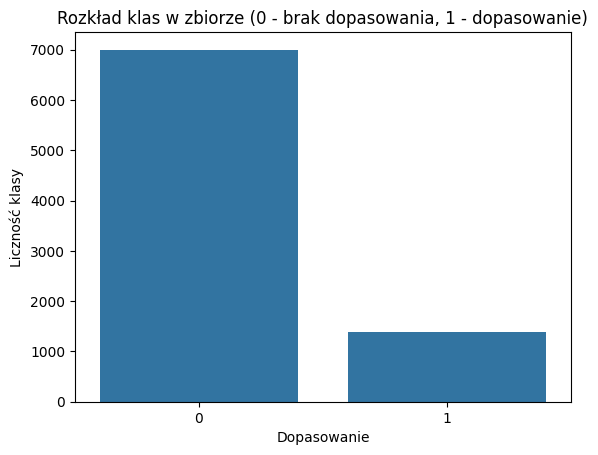

In [113]:
sns.countplot(
    data=df,
    x='match'
)
plt.title("Rozkład klas w zbiorze (0 - brak dopasowania, 1 - dopasowanie)")
plt.xlabel("Dopasowanie")
plt.ylabel("Liczność klasy")

In [114]:
df['gender'] = df['gender'].map({'female': 0, 'male': 1})

## Zadanie 1.2: Przygotowanie danych
- W świecie aplikacji randkowych nie możemy korzystać z wiedzy "z przyszłości". Usuń zmienne stanowiące wyciek wiedzy (np. decyzje, wrażenia z randki, zgadywanie sympatii), pozostawiając tylko atrybuty profilowe dostępne w momencie rekomendacji. Opis zmiennych znajdziesz w pobranym zbiorze w polu 'DESCR'.
- Stwórz "odcisk palca" (id) użytkownika na podstawie profilu, by pogrupować interakcje tego samego użytkownika (lub raczej typu użytkownika o danych preferencjach). Podziel dane na uczące i testowe w taki sposób, by w zbiorze testowym dany użytkownik miał dokładnie stałą liczbę (np. 5) prób. Nie dodawaj id do danych, trzymaj je w osobnej zmiennej.

In [115]:
# USUNIĘCIĘ WIEDZY "Z PRZYSZŁOŚCI"
columns_to_drop = [
    'decision', 'decision_o', 'met', 'guess_prob_liked', 'like', 'interests_correlate',
    'd_like', 'd_guess_prob_liked', 'd_interests_correlate',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
    'has_null',
    'expected_happy_with_sd_people', 'expected_num_interested_in_me', 'expected_num_matches',
    'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
cols = [col for col in df.columns]
print(cols)

['wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',

Text(0.5, 1.0, 'Macierz korelacji - oczekiwania wobec partnera')

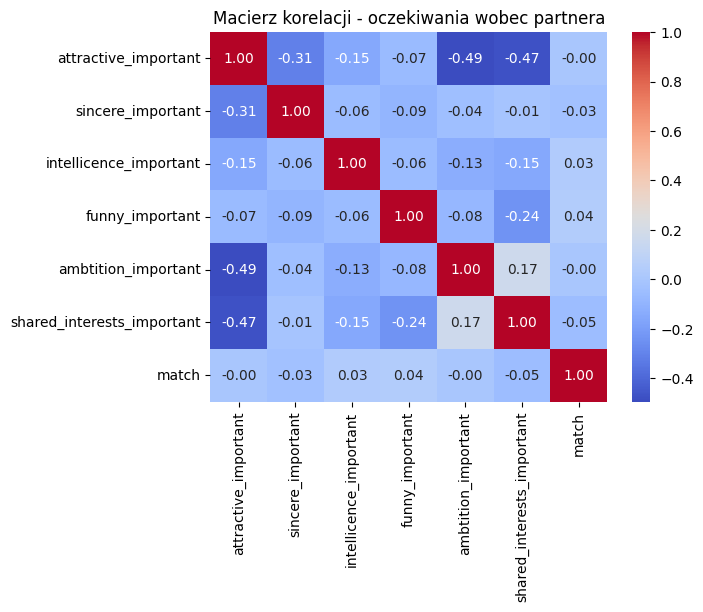

In [116]:
# MACIERZ KORELACJI
cols_to_matrix = ['attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'match']
corr_matrix = df[cols_to_matrix].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji - oczekiwania wobec partnera")

Text(0.5, 1.0, 'Macierz korelacji - cechy własne')

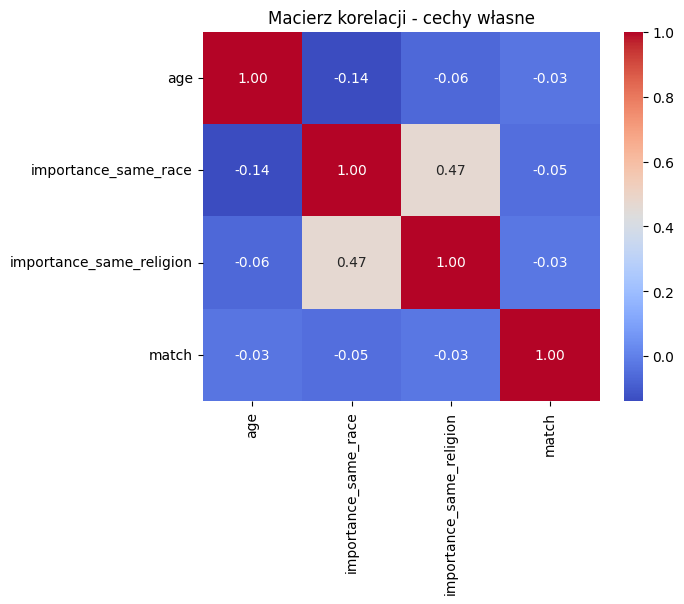

In [117]:
cols_to_matrix = ['age', 'importance_same_race', 'importance_same_religion', 'match']
corr_matrix = df[cols_to_matrix].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji - cechy własne")

In [118]:
# CYFROWY ODCISK PALCA
profile_features = ['wave', 'gender', 'age', 'race', 'importance_same_race', 'importance_same_religion']

temp_df = df[profile_features].astype(str)
df['user_id'] = temp_df.groupby(profile_features).ngroup()

user_counts = df['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
df_filtered = df[df['user_id'].isin(valid_users)].copy()

unique_users = df_filtered['user_id'].unique()

train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

df_train = df_filtered[df_filtered['user_id'].isin(train_users)].copy()
df_test_full = df_filtered[df_filtered['user_id'].isin(test_users)].copy()

df_test = df_test_full.groupby('user_id').sample(n=5, random_state=42).copy()

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

train_ids = df_train.pop('user_id')
test_ids = df_test.pop('user_id')

y_train = df_train.pop('match').astype(int)
y_test = df_test.pop('match').astype(int)

X_train = df_train
X_test = df_test

print(f"Dane treningowe (X_train): {X_train.shape}, Klasy: {np.bincount(y_train)}")
print(f"Dane testowe (X_test):  {X_test.shape}, Klasy: {np.bincount(y_test)}")

Dane treningowe (X_train): (6694, 82), Klasy: [5612 1082]
Dane testowe (X_test):  (545, 82), Klasy: [451  94]


## Zadanie 1.3: Model Bazowy i Wizualizacja Problemu
- Zaadresuj braki w danych.
- Wymyśl własne dodatkowe cechy np. różnica w ocenie atrakcyjności. Wytrenuj model na danych zawierających nowe cechy.
- Wyucz naiwne predyktory – większościowy i losowy.
- Wyucz podstawowy model (np. regresję logistyczną, drzewo decyzyjne) i wygeneruj classification_report_imbalanced (z biblioteki imbalanced-learn). Zaobserwuj, jak model radzi sobie z predykcjami dla klasy mniejszościowej.

In [119]:
missing = df.isnull().sum()
df_missing = pd.DataFrame({'Liczba braków': missing, 'Rodzaj kolumny': df.dtypes})
df_missing = df_missing[df_missing['Liczba braków'] > 0]
print(f"Braki danych:")
print(df_missing)

Braki danych:
                            Liczba braków Rodzaj kolumny
age                                    95        float64
age_o                                 104        float64
race                                   63       category
race_o                                 73       category
importance_same_race                   79        float64
importance_same_religion               79        float64
field                                  63       category
pref_o_attractive                      89        float64
pref_o_sincere                         89        float64
pref_o_intelligence                    89        float64
pref_o_funny                           98        float64
pref_o_ambitious                      107        float64
pref_o_shared_interests               129        float64
attractive_important                   79        float64
sincere_important                      79        float64
intellicence_important                 79        float64
funny_important  

In [120]:
# UZUPEŁNIANIE BRAKÓW
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_num_array = num_imputer.fit_transform(X_train[num_cols])
survived_num_cols = num_imputer.get_feature_names_out(num_cols)

X_train_num = pd.DataFrame(X_train_num_array, columns=survived_num_cols)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=survived_num_cols)

X_train_cat_array = cat_imputer.fit_transform(X_train[cat_cols])
survived_cat_cols = cat_imputer.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat_array, columns=survived_cat_cols)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=survived_cat_cols)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

print(X_train.isnull().sum())

wave                    0
age                     0
age_o                   0
d_age                   0
importance_same_race    0
                       ..
d_movies                0
d_concerts              0
d_music                 0
d_shopping              0
d_yoga                  0
Length: 82, dtype: int64


In [121]:
print(X_train.columns)

Index(['wave', 'age', 'age_o', 'd_age', 'importance_same_race',
       'importance_same_religion', 'pref_o_attractive', 'pref_o_sincere',
       'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
       'pref_o_shared_interests', 'attractive_important', 'sincere_important',
       'intellicence_important', 'funny_important', 'ambtition_important',
       'shared_interests_important', 'attractive', 'sincere', 'intelligence',
       'funny', 'ambition', 'sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'gender',
       'd_d_age', 'race', 'race_o', 'samerace', 'd_importance_same_race',
       'd_importance_same_religion', 'field', 'd_pref_o_attractive',
       'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny',
       'd_pref_o_ambitious', 'd_pref_o_shared_interests',
       'd_attractive_important', 'd_sincere_important',
       'd_in

In [122]:
# NOWE CECHY
def new_features(df):
  df_new = df.copy()
  # 1. wskaźnik samooceny
  cols_to_self_esteem = ['attractive','sincere','intelligence','funny','ambition']
  df_new['self_esteem'] = df_new[cols_to_self_esteem].sum(axis=1)

  # 2. powierzchowność
  df_new['superficiality'] = df_new['attractive_important'] / (df_new['intellicence_important'] + df_new['sincere_important'] + 0.0001)

  # 3. różnica atrakcyjności
  df_new['diff_attract'] = df_new['attractive_important'] - df_new['attractive']

  # 4. entuzjasta hobby
  hobby_cols = ['sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga']
  df_new['hobby_enthusiasm'] = df_new[hobby_cols].mean(axis=1)
  return df_new

X_train = new_features(X_train)
X_test = new_features(X_test)
df = new_features(df)

Text(0.5, 1.0, 'Macierz korelacji - nowe cechy')

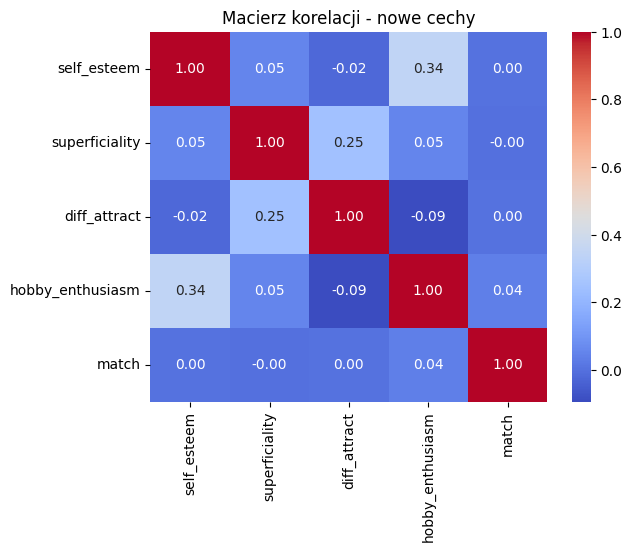

In [123]:
cols_to_matrix = ['self_esteem', 'superficiality', 'diff_attract', 'hobby_enthusiasm', 'match']
corr_matrix = df[cols_to_matrix].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji - nowe cechy")

In [124]:
# NAIWNE MODELE - WIĘKSZOŚCIOWY I LOSOWY
majority_classifier = DummyClassifier(strategy='most_frequent')
majority_classifier.fit(X_train, y_train)
y_pred_majority = majority_classifier.predict(X_test)

print("=== PREDYKATOR WIĘKSZOŚCIOWY ===")
print(classification_report_imbalanced(y_test, y_pred_majority))

=== PREDYKATOR WIĘKSZOŚCIOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      1.00      0.00      0.91      0.00      0.00       451
          1       0.00      0.00      1.00      0.00      0.00      0.00        94

avg / total       0.68      0.83      0.17      0.75      0.00      0.00       545



In [125]:
random_classifier = DummyClassifier(strategy='stratified', random_state=42)
random_classifier.fit(X_train, y_train)
y_pred_random = random_classifier.predict(X_test)

print("=== PREDYKATOR LOSOWY ===")
print(classification_report_imbalanced(y_test, y_pred_random))


=== PREDYKATOR LOSOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.83      0.23      0.84      0.44      0.21       451
          1       0.22      0.23      0.83      0.23      0.44      0.18        94

avg / total       0.73      0.73      0.34      0.73      0.44      0.20       545



In [126]:
# ENCODING
X_train_encoded = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, dtype=float)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0.0)


In [127]:
# DRZEWO DECYZYJNE
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_encoded, y_train)
y_pred_tree = tree_model.predict(X_test_encoded)

print("=== DRZEWO DECYZYJNE ===")
print(classification_report_imbalanced(y_test, y_pred_tree))

=== DRZEWO DECYZYJNE ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.99      0.01      0.90      0.10      0.01       451
          1       0.17      0.01      0.99      0.02      0.10      0.01        94

avg / total       0.71      0.82      0.18      0.75      0.10      0.01       545



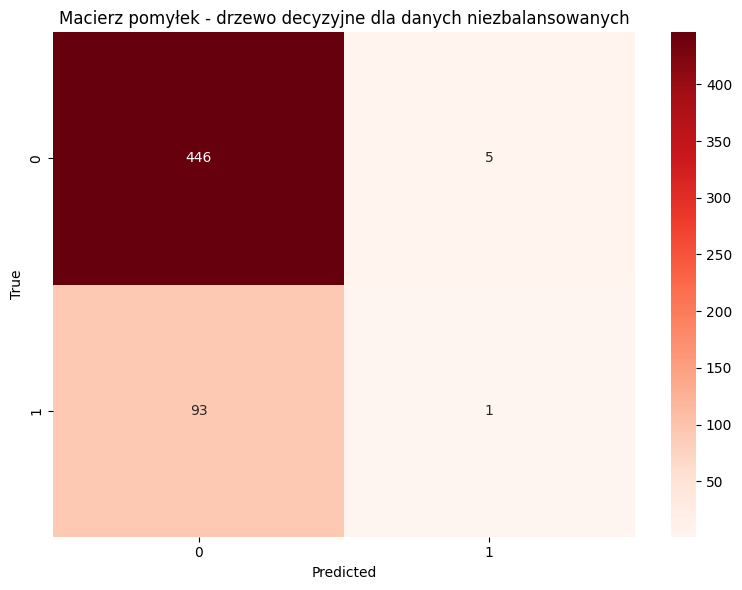

In [128]:
conf_matrix = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Macierz pomyłek - drzewo decyzyjne dla danych niezbalansowanych')
plt.tight_layout()
plt.show()


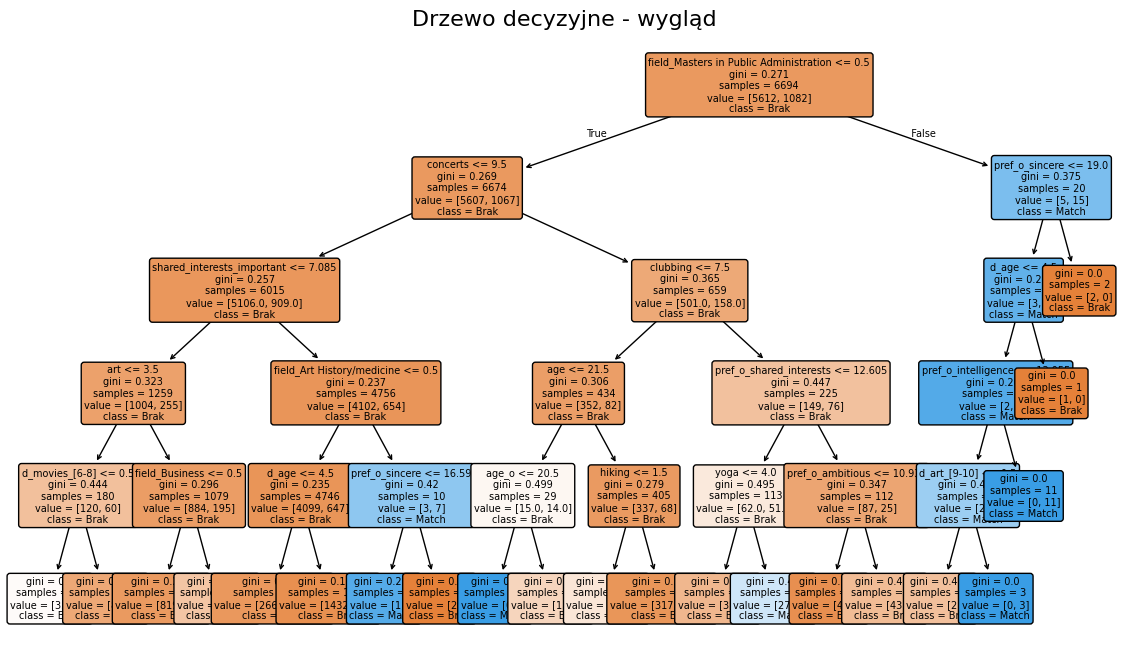

In [129]:
plt.figure(figsize=(14, 8))
plot_tree(tree_model,
          feature_names=X_train_encoded.columns,
          class_names=['Brak', 'Match'],
          filled=True,
          rounded=True,
          fontsize=7)

plt.title("Drzewo decyzyjne - wygląd", fontsize=16)
plt.show()

## Zadanie 1.4: Techniki Resamplingu
Porównaj poniższe metody resamplingu danych. Zwizualizuj ich działanie przy pomocy t-SNE.

- Zwizualizuj przestrzeń danych przed zastosowaniem metod resamplingu (by przyspieszyć obliczenia wykorzystaj losowy podzbiór, np. 1500 próbek).
- Zastosuj algorytm SMOTE do wykonania oversamplingu klasy mniejszościowej (generowania syntetycznych przykładów).
- Zbuduj potok (imblearn.pipeline.Pipeline) łączący RandomUnderSampler oraz SMOTE.
- Spróbuj metody hybrydowej np. SMOTE+ENN.

Jak działają powyższe metody? Która daje lepsze rezultaty i dlaczego?

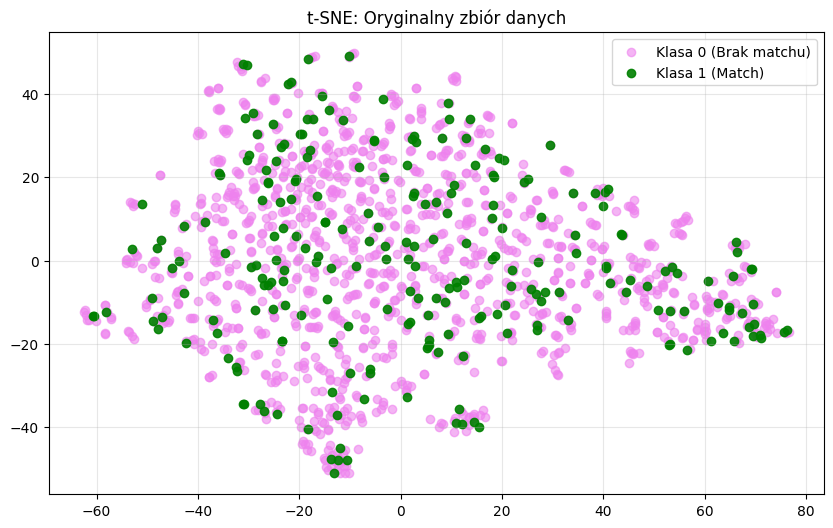

In [130]:
# t-SNE dla oryginalnych danych
sample_size = 1500
X_simple_tsne = X_train_encoded.sample(n=sample_size, random_state=42)
y_simple_tsne = y_train.loc[X_simple_tsne.index]

tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_simple_tsne)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[y_simple_tsne==0, 0], X_tsne[y_simple_tsne==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
plt.scatter(X_tsne[y_simple_tsne==1, 0], X_tsne[y_simple_tsne==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')

plt.title('t-SNE: Oryginalny zbiór danych')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

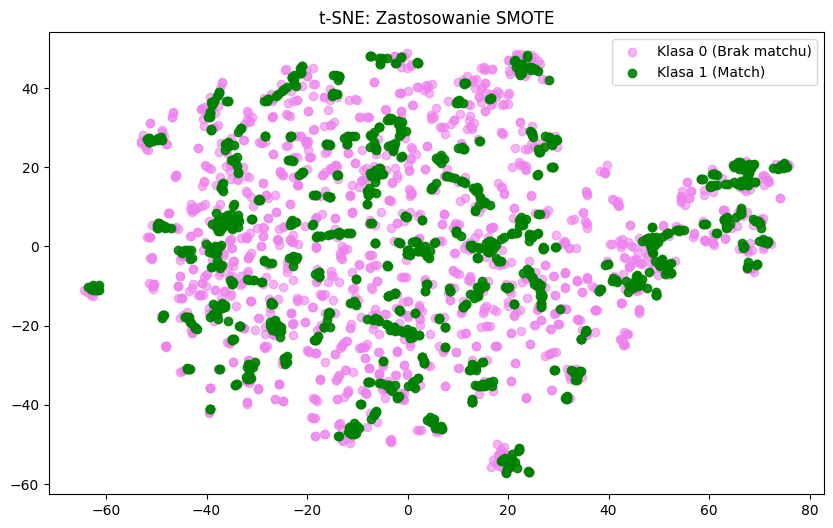

In [131]:
# SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_smote, y_smote = smote.fit_resample(X_simple_tsne, y_simple_tsne)

X_smote_tsne = tsne.fit_transform(X_smote)

plt.figure(figsize=(10, 6))
plt.scatter(X_smote_tsne[y_smote==0, 0], X_smote_tsne[y_smote==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
plt.scatter(X_smote_tsne[y_smote==1, 0], X_smote_tsne[y_smote==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')

plt.title('t-SNE: Zastosowanie SMOTE')
plt.legend()
plt.show()

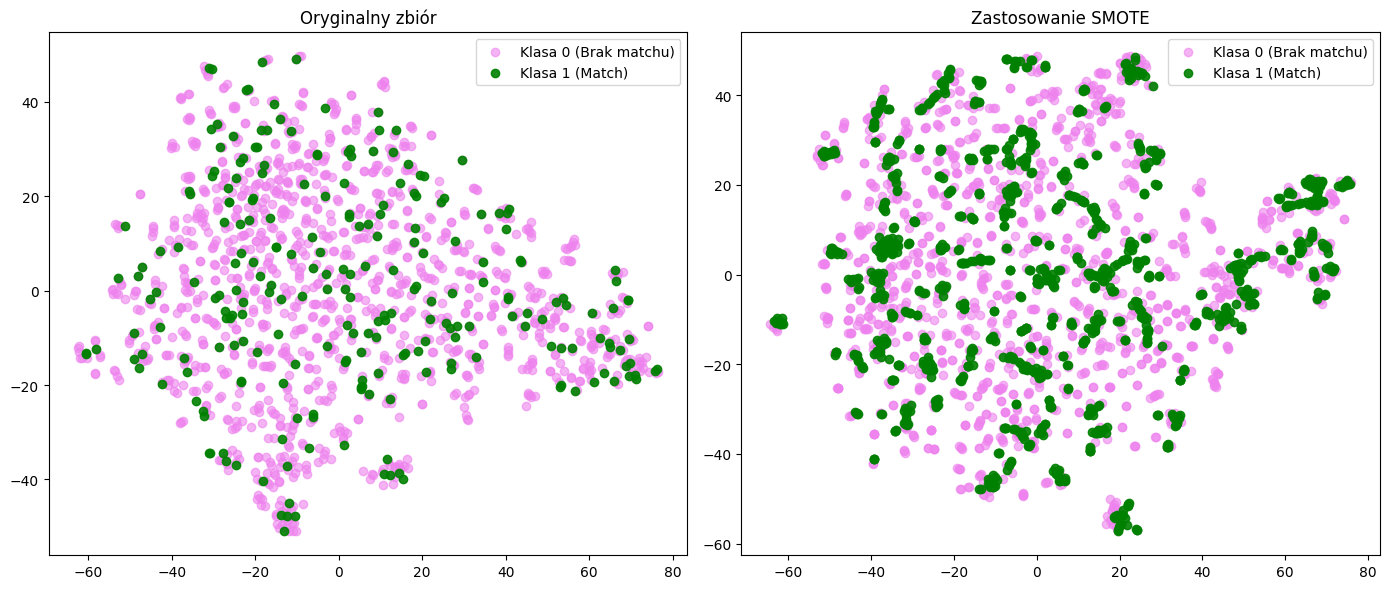

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_tsne[y_simple_tsne==0, 0], X_tsne[y_simple_tsne==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[0].scatter(X_tsne[y_simple_tsne==1, 0], X_tsne[y_simple_tsne==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[0].set_title("Oryginalny zbiór")
axes[0].legend()

axes[1].scatter(X_smote_tsne[y_smote==0, 0], X_smote_tsne[y_smote==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[1].scatter(X_smote_tsne[y_smote==1, 0], X_smote_tsne[y_smote==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[1].set_title("Zastosowanie SMOTE")
axes[1].legend()

plt.tight_layout()
plt.show()

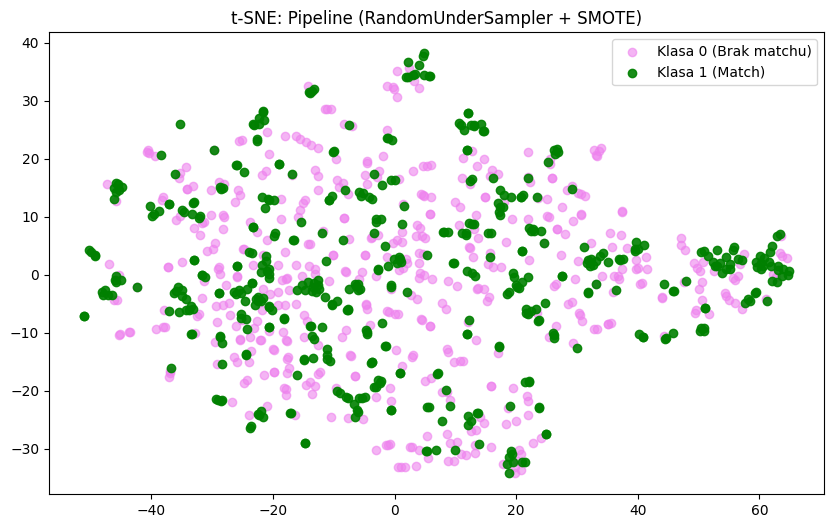

In [133]:
# Pipeline: RandomUnderSampler + SMOTE
under_sampler = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

pipeline = Pipeline(steps=[('under_sampler', under_sampler), ('smote', smote)])

X_pipeline, y_pipeline = pipeline.fit_resample(X_simple_tsne, y_simple_tsne)

X_pipeline_tsne = tsne.fit_transform(X_pipeline)

plt.figure(figsize=(10, 6))
plt.scatter(X_pipeline_tsne[y_pipeline==0, 0], X_pipeline_tsne[y_pipeline==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
plt.scatter(X_pipeline_tsne[y_pipeline==1, 0], X_pipeline_tsne[y_pipeline==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')

plt.title('t-SNE: Pipeline (RandomUnderSampler + SMOTE)')
plt.legend()
plt.show()


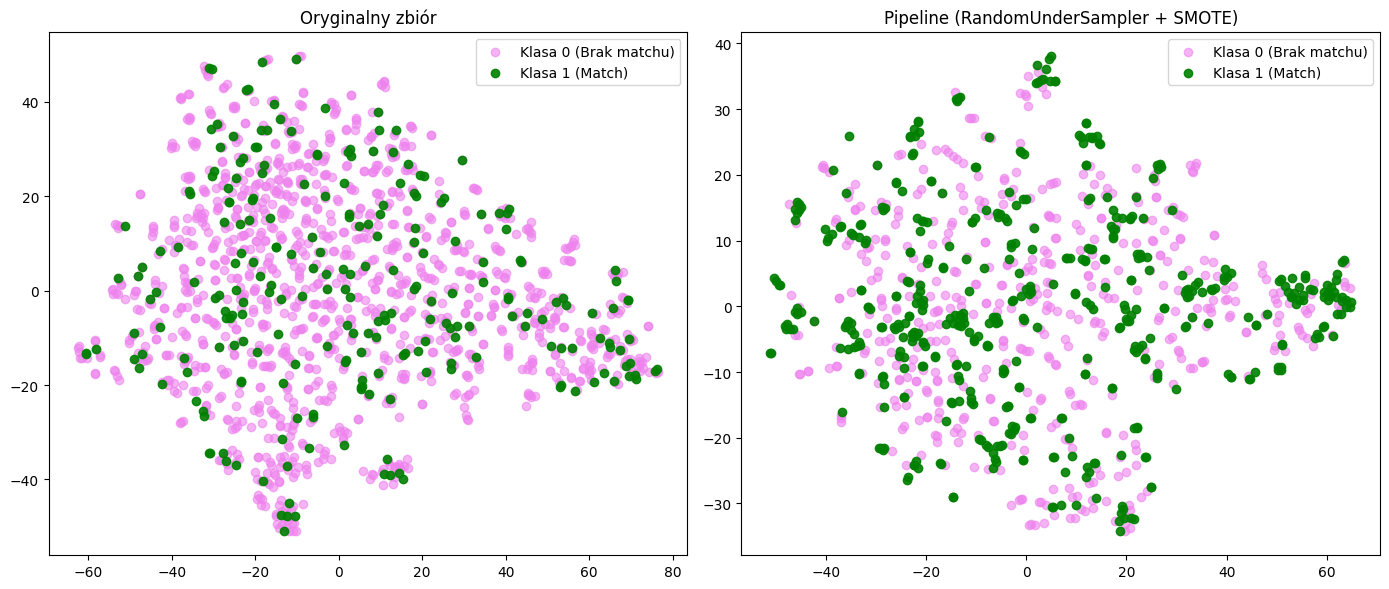

In [134]:
# oryginalny zbiór - pipeline
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne[y_simple_tsne==0, 0], X_tsne[y_simple_tsne==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[0].scatter(X_tsne[y_simple_tsne==1, 0], X_tsne[y_simple_tsne==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[0].set_title("Oryginalny zbiór")
axes[0].legend()

axes[1].scatter(X_pipeline_tsne[y_pipeline==0, 0], X_pipeline_tsne[y_pipeline==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[1].scatter(X_pipeline_tsne[y_pipeline==1, 0], X_pipeline_tsne[y_pipeline==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[1].set_title("Pipeline (RandomUnderSampler + SMOTE)")
axes[1].legend()

plt.tight_layout()
plt.show()

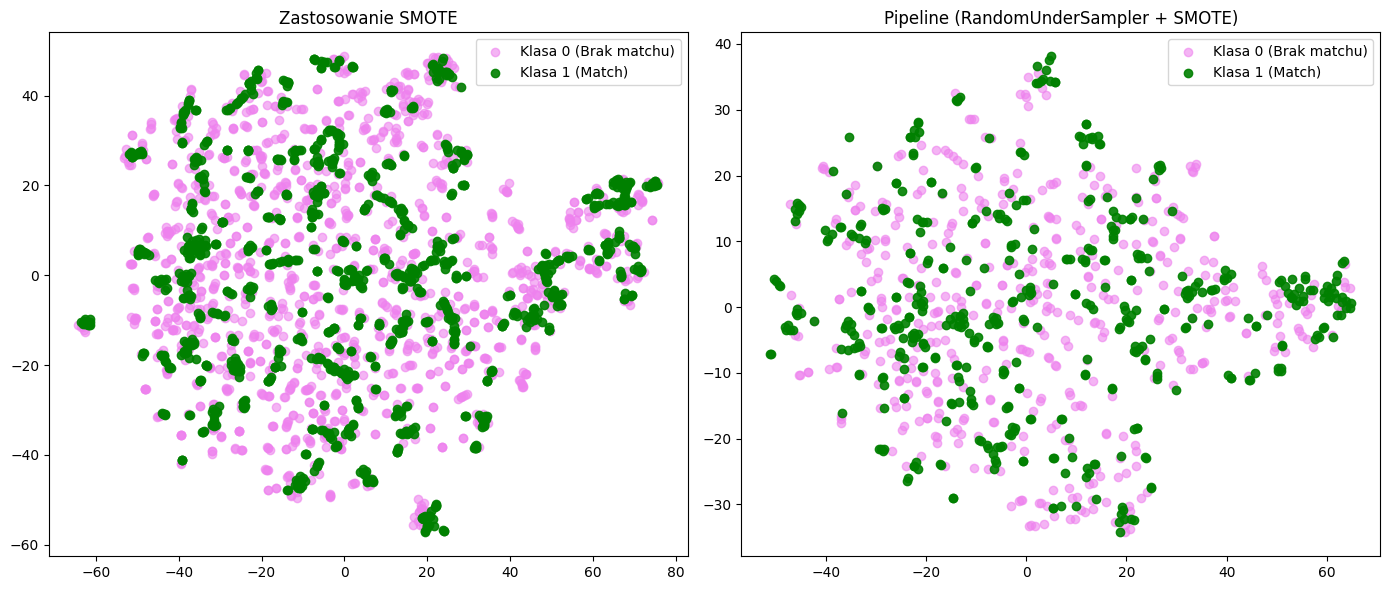

In [135]:
# smote - pipeline
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_smote_tsne[y_smote==0, 0], X_smote_tsne[y_smote==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[0].scatter(X_smote_tsne[y_smote==1, 0], X_smote_tsne[y_smote==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[0].set_title("Zastosowanie SMOTE")
axes[0].legend()

axes[1].scatter(X_pipeline_tsne[y_pipeline==0, 0], X_pipeline_tsne[y_pipeline==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[1].scatter(X_pipeline_tsne[y_pipeline==1, 0], X_pipeline_tsne[y_pipeline==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[1].set_title("Pipeline (RandomUnderSampler + SMOTE)")
axes[1].legend()

plt.tight_layout()
plt.show()

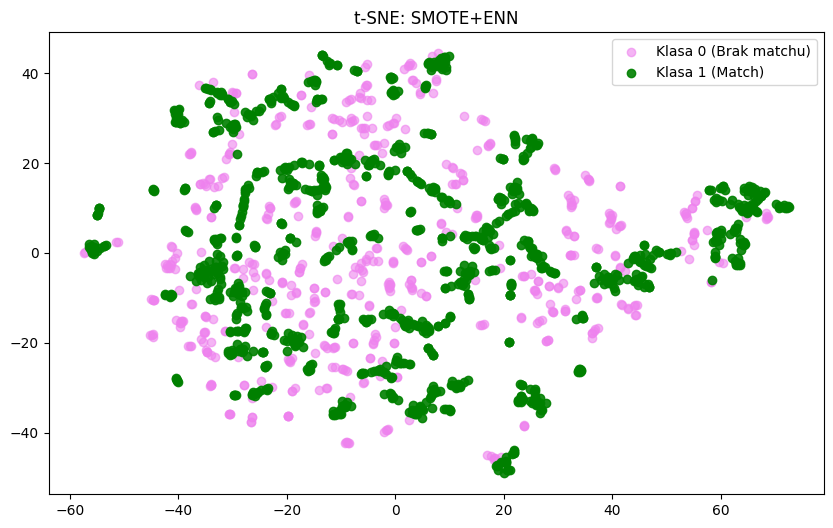

In [136]:
# SMOTE+ENN
smote_enn = SMOTEENN(sampling_strategy='minority', random_state=42)
X_smote_enn, y_smote_enn = smote_enn.fit_resample(X_simple_tsne, y_simple_tsne)

X_smote_enn_tsne = tsne.fit_transform(X_smote_enn)

plt.figure(figsize=(10, 6))
plt.scatter(X_smote_enn_tsne[y_smote_enn==0, 0], X_smote_enn_tsne[y_smote_enn==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
plt.scatter(X_smote_enn_tsne[y_smote_enn==1, 0], X_smote_enn_tsne[y_smote_enn==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')

plt.title('t-SNE: SMOTE+ENN')
plt.legend()
plt.show()

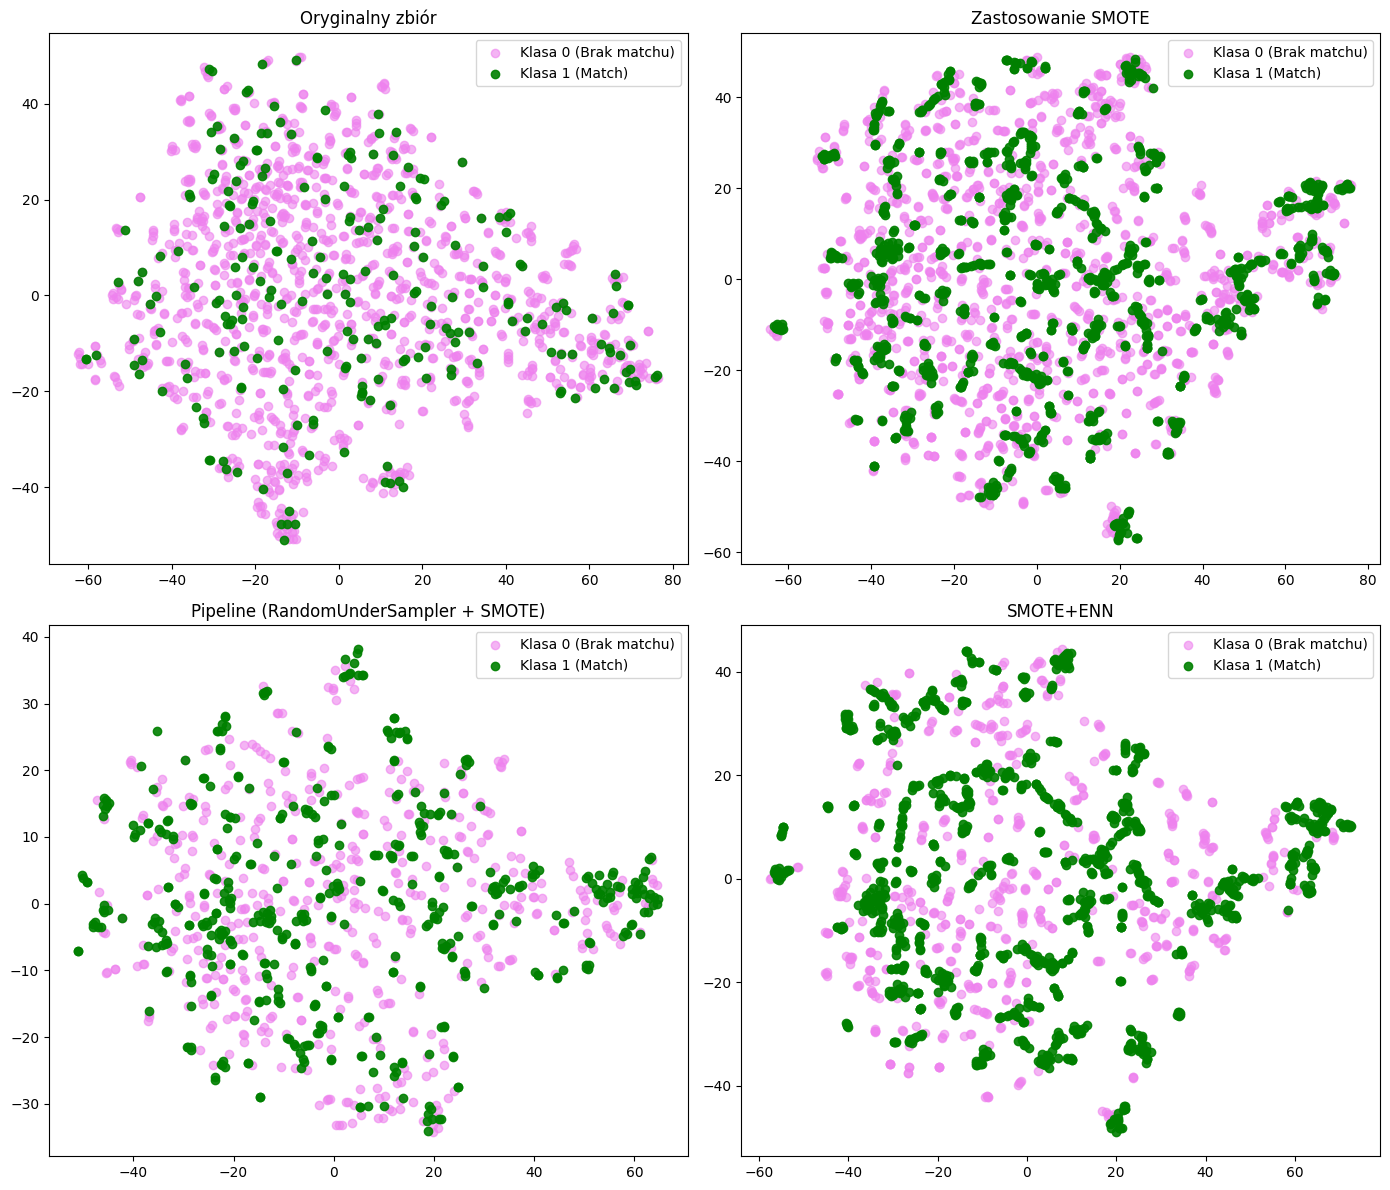

In [137]:
# tsne - SMOTE - pipeline - SMOTEENN
fg, axes = plt.subplots(2, 2, figsize=(14, 12))

#tsne
axes[0][0].scatter(X_tsne[y_simple_tsne==0, 0], X_tsne[y_simple_tsne==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[0][0].scatter(X_tsne[y_simple_tsne==1, 0], X_tsne[y_simple_tsne==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[0][0].set_title("Oryginalny zbiór")
axes[0][0].legend()

#SMOTE
axes[0][1].scatter(X_smote_tsne[y_smote==0, 0], X_smote_tsne[y_smote==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[0][1].scatter(X_smote_tsne[y_smote==1, 0], X_smote_tsne[y_smote==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[0][1].set_title("Zastosowanie SMOTE")
axes[0][1].legend()

#Pipeline
axes[1][0].scatter(X_pipeline_tsne[y_pipeline==0, 0], X_pipeline_tsne[y_pipeline==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[1][0].scatter(X_pipeline_tsne[y_pipeline==1, 0], X_pipeline_tsne[y_pipeline==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[1][0].set_title("Pipeline (RandomUnderSampler + SMOTE)")
axes[1][0].legend()

#SMOTEENN
axes[1][1].scatter(X_smote_enn_tsne[y_smote_enn==0, 0], X_smote_enn_tsne[y_smote_enn==0, 1], label='Klasa 0 (Brak matchu)', alpha=0.6, c='violet')
axes[1][1].scatter(X_smote_enn_tsne[y_smote_enn==1, 0], X_smote_enn_tsne[y_smote_enn==1, 1], label='Klasa 1 (Match)', alpha=0.9, c='green')
axes[1][1].set_title("SMOTE+ENN")
axes[1][1].legend()

plt.tight_layout()
plt.show()

### Jak działają powyższe metody? Która daje lepsze rezultaty i dlaczego?

- SMOTE - generuje sztuczne obserwacje klasy mniejszościowej (przypadki Matchów) na podstawie najbliższych sąsiadów, tak aby wyrównać liczebność obu klas. W naszym przypadku spowodowało to duże zagęszczenie obu klas i wspólne nakładanie się na siebie.

- Pipeline (RandomUnderSampler + SMOTE) - najpierw model losowo usuwa część klasy większościowej (niematche), a dopiero później wyrównuje liczebność obu klas za pomocą SMOTE dla klasy mniejszościowej. Udało się w miarę zredukować zagęszczenie na wykresie.

- SMOTEENN - połączenie dodawania sztucznych obserwacji za pomocą SMOTE z odkurzaniem przestrzeni za pomocą ENN. ENN usuwa z obu klas punkty, które są otoczone przez przez klasę przeciwną, uznając je za szum. Dzięki temu na wykresie udało się lepiej odesparować grupy klas.

## Zadanie 1.5: Modele Ensemble dla Danych Niezbalansowanych
- Wykorzystaj algorytmy dedykowane dla problemu niezbalansowania klas z biblioteki imbalanced-learn: np. `BalancedRandomForestClassifier` lub `EasyEnsembleClassifier`. Wykorzystaj też sklearn.ensemble.`RandomForestClassifier` (ustaw parametr class_weight). Skonfrontuj ich wyniki z poprzednimi podejściami. Które algorytmy radzą sobie lepiej i dlaczego?

- Narysuj krzywe ROC (Receiver Operating Characteristic) oraz Precision-Recall. Oblicz pola pod krzywymi (AUC, AP). Która krzywa lepiej oddaje działanie algorytmu w zadaniu rekomendacji potencjalnych par?

In [138]:
# RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=5)
rf_classifier.fit(X_train_encoded, y_train)
y_pred_rf = rf_classifier.predict(X_test_encoded)

print("=== RandomForestClassifier ===")
print(classification_report_imbalanced(y_test, y_pred_rf))

=== RandomForestClassifier ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.75      0.32      0.79      0.49      0.25       451
          1       0.21      0.32      0.75      0.25      0.49      0.23        94

avg / total       0.73      0.68      0.39      0.70      0.49      0.25       545



In [139]:
# BalancedRandomForestClassifier
brf_classifier = BalancedRandomForestClassifier(n_estimators=100, random_state=42, max_depth=9)
brf_classifier.fit(X_train_encoded, y_train)
y_pred_brf = brf_classifier.predict(X_test_encoded)

print("=== BalancedRandomForestClassifier ===")
print(classification_report_imbalanced(y_test, y_pred_brf))

=== BalancedRandomForestClassifier ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.82      0.19      0.82      0.40      0.17       451
          1       0.18      0.19      0.82      0.19      0.40      0.15        94

avg / total       0.72      0.71      0.30      0.71      0.40      0.16       545



In [140]:
print("=== PREDYKATOR WIĘKSZOŚCIOWY ===")
print(classification_report_imbalanced(y_test, y_pred_majority))
print("=== PREDYKATOR LOSOWY ===")
print(classification_report_imbalanced(y_test, y_pred_random))
print("=== DRZEWO DECYZYJNE ===")
print(classification_report_imbalanced(y_test, y_pred_tree))
#

=== PREDYKATOR WIĘKSZOŚCIOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      1.00      0.00      0.91      0.00      0.00       451
          1       0.00      0.00      1.00      0.00      0.00      0.00        94

avg / total       0.68      0.83      0.17      0.75      0.00      0.00       545

=== PREDYKATOR LOSOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.83      0.23      0.84      0.44      0.21       451
          1       0.22      0.23      0.83      0.23      0.44      0.18        94

avg / total       0.73      0.73      0.34      0.73      0.44      0.20       545

=== DRZEWO DECYZYJNE ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.99      0.01      0.90      0.10      0.01       451
          1       0.17      0.01      0.99      0.02      0.10      0.01       

#### Porównanie modeli

|Model|*Recall (0)*|*Recall(1)*|*Recall (avg)*|*Precision (1)*|*F1 (1)*|
|---|---|---|---|---|---|
|Predykator większościowy|1.0|0.0|0.83|0.0|0.0|
|Predykator losowy|0.83|0.23|0.73|0.22|0.23|
|Pojedyncze drzewo decyzyjne|0.99|0.01|0.82|0.17|0.02|
|Las Losowy|0.75|0.32|0.68|0.21|0.25|
|Zbalansowany Las Losowy|0.82|0.17|0.71|0.18|0.19|


Widać bezużyteczność modeli naiwnych. Model większościowy w ciemno przypisał każdemu przypadkowi klasę 0, co gwarantuje nieskuteczność na klasie 1. Predykator losowy przypisuje klasę za pomocą losowania na bazie stosunku między klasami, co nie daje gwarancji rzetelnych wyników. Pojedyncze drzewo decyzyjne również wpadło w pułapkę niezbalansowanych danych. `RandomForestClassifier` przyniósł najlepszy balans między recallem i precyzją dla obu klas. Spadek czułości dla klasy 0 przyniósł najwyższą wartość recallu dla klasy 1 spośrów wszystkich rozważanych modeli. Dowodem jest najwyższy wynik spośród wszystkich modeli dla f1-score.

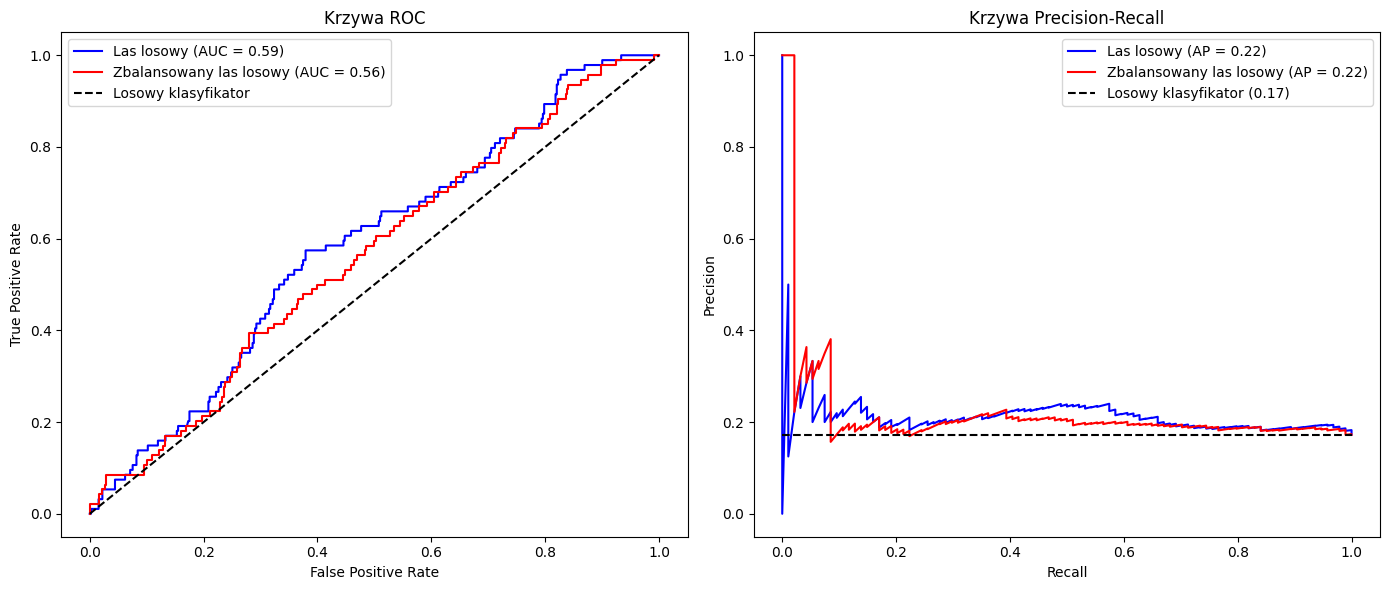

In [141]:
# Krzywe ROC i Precision-Recall dla lasu losowego i zbalansowanego lasu losowego na danych niezbalansowanych
y_prob_rf = rf_classifier.predict_proba(X_test_encoded)[:, 1]
y_prob_brf = brf_classifier.predict_proba(X_test_encoded)[:, 1]

frp_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
frp_brf, tpr_brf, _ = roc_curve(y_test, y_prob_brf)

roc_auc_rf = auc(frp_rf, tpr_rf)
roc_auc_brf = auc(frp_brf, tpr_brf)

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_brf, rec_brf, _ = precision_recall_curve(y_test, y_prob_brf)

ap_rf = average_precision_score(y_test, y_prob_rf)
ap_brf = average_precision_score(y_test, y_prob_brf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(frp_rf, tpr_rf, label=f'Las losowy (AUC = {roc_auc_rf:.2f})', color='blue')
axes[0].plot(frp_brf, tpr_brf, label=f'Zbalansowany las losowy (AUC = {roc_auc_brf:.2f})', color='red')
axes[0].plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Krzywa ROC')
axes[0].legend()

baseline = sum(y_test == 1) / len(y_test)
axes[1].plot(rec_rf, prec_rf, label=f'Las losowy (AP = {ap_rf:.2f})', color='blue') # Kolejność: X=Recall, Y=Precision
axes[1].plot(rec_brf, prec_brf, label=f'Zbalansowany las losowy (AP = {ap_brf:.2f})', color='red')
axes[1].plot([0, 1], [baseline, baseline], 'k--', label=f'Losowy klasyfikator ({baseline:.2f})') # Pozioma linia!
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Krzywa Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()


Krzywa ROC to zależność między odsetkiem TP (prawdziwie pozytywne) a odsetkiem FP (fałszywie pozytywnych). $FPR=\frac{FP}{FP+TN}$. Ponieważ w naszych danych klasa 0 stanowi zdecydowaną większość, to wartość TN (prawdziwie negatywnych), czyli słusznie odrzuconych kandydatów jest ogromna. Prowadzi to do w miarę porządnego kształtu krzywej ROC, nawet gdy model pomili się wielokrotnie.

Krzywa Precision-Recall pokazuje zależność między precyzją a czułością. $Precision=\frac{TP}{TP+FP}$, $Recall=\frac{TP}{TP+FN}$. Ponieważ chcemy, aby nasz model mylił się jak najrzadziej, musimy skupić się na poprawnym dobieraniu kandydatów na matche. Dlatego chcemy skupić się na precyzji, czyli nasz model pod względem wyników lepiej oddaje krzywa PR.

In [142]:
# las losowy na danych po SMOTE
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=9)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_encoded)

In [143]:
# las losowy na danych po Pipelinie (RUS + SMOTE)
X_train_pipeline, y_train_pipeline = pipeline.fit_resample(X_train_encoded, y_train)
rf_pipeline = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

rf_pipeline.fit(X_train_pipeline, y_train_pipeline)
y_pred_pipeline = rf_pipeline.predict(X_test_encoded)

In [144]:
# las losowy na danych po SMOTE+ENN
X_train_smenn, y_train_smenn = smote_enn.fit_resample(X_train_encoded, y_train)
rf_smenn = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7)

rf_smenn.fit(X_train_smenn, y_train_smenn)
y_pred_smenn = rf_smenn.predict(X_test_encoded)

In [145]:
print("=== RandomForest trenowany na danych po SMOTE ===")
print(classification_report_imbalanced(y_test, y_pred_smote))

print("=== RandomForest trenowany na danych ze SMOTE+ENN ===")
print(classification_report_imbalanced(y_test, y_pred_smenn))

print("=== RandomForest trenowany na danych po Pipeline ===")
print(classification_report_imbalanced(y_test, y_pred_pipeline))


=== RandomForest trenowany na danych po SMOTE ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.83      0.99      0.00      0.90      0.00      0.00       451
          1       0.00      0.00      0.99      0.00      0.00      0.00        94

avg / total       0.68      0.82      0.17      0.75      0.00      0.00       545

=== RandomForest trenowany na danych ze SMOTE+ENN ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.86      0.62      0.50      0.72      0.56      0.32       451
          1       0.22      0.50      0.62      0.30      0.56      0.31        94

avg / total       0.75      0.60      0.52      0.65      0.56      0.31       545

=== RandomForest trenowany na danych po Pipeline ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.89      0.16      0.86      0.38      0.15       451
      

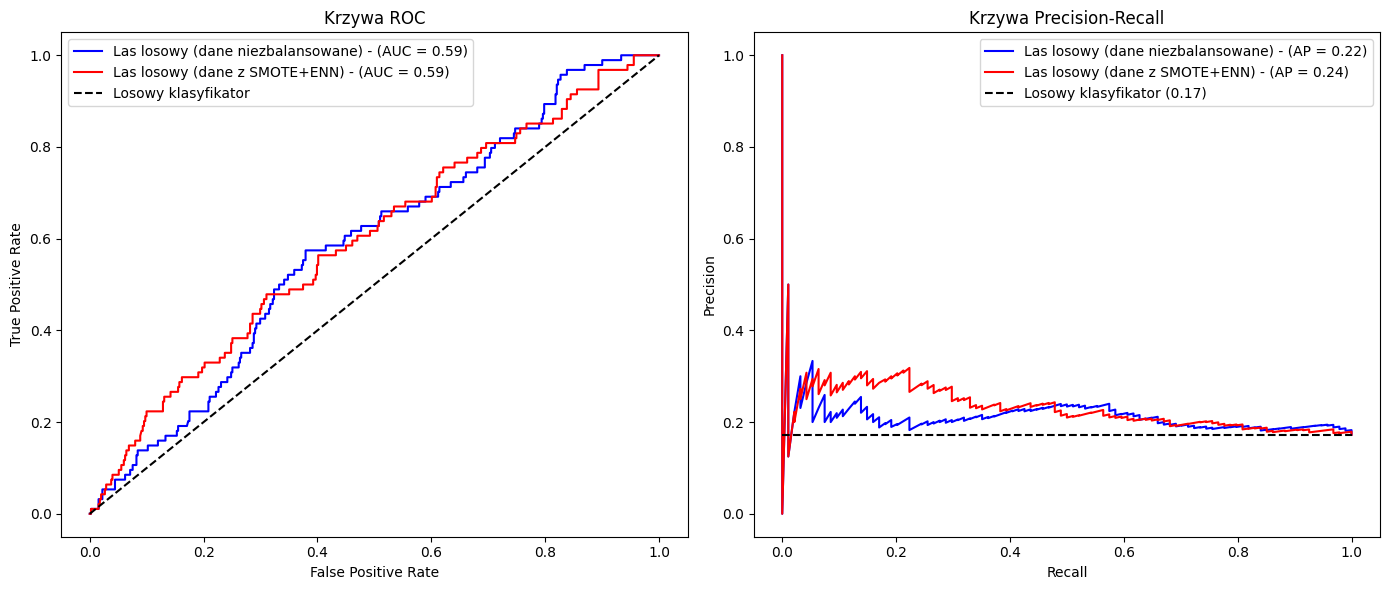

In [146]:
# krzywa roc i pr dla lasu losowego dla danych niezbalansowanych i po SMOTEENN
y_prob_rf_smenn = rf_smenn.predict_proba(X_test_encoded)[:, 1]

fpr_rf_smenn, tpr_rf_smenn, _ = roc_curve(y_test, y_prob_rf_smenn)
roc_auc_rf_smenn = auc(fpr_rf_smenn, tpr_rf_smenn)

prec_rf_smenn, rec_rf_smenn, _ = precision_recall_curve(y_test, y_prob_rf_smenn)
ap_rf_smenn = average_precision_score(y_test, y_prob_rf_smenn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(frp_rf, tpr_rf, label=f'Las losowy (dane niezbalansowane) - (AUC = {roc_auc_rf:.2f})', color='blue')
axes[0].plot(fpr_rf_smenn, tpr_rf_smenn, label=f'Las losowy (dane z SMOTE+ENN) - (AUC = {roc_auc_rf_smenn:.2f})', color='red')
axes[0].plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Krzywa ROC')
axes[0].legend()

baseline = sum(y_test == 1) / len(y_test)
axes[1].plot(rec_rf, prec_rf, label=f'Las losowy (dane niezbalansowane) - (AP = {ap_rf:.2f})', color='blue')
axes[1].plot(rec_rf_smenn, prec_rf_smenn, label=f'Las losowy (dane z SMOTE+ENN) - (AP = {ap_rf_smenn:.2f})', color='red')
axes[1].plot([0, 1], [baseline, baseline], 'k--', label=f'Losowy klasyfikator ({baseline:.2f})') # Pozioma linia!
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Krzywa Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

## Zadanie 2.1: Ewaluacja w kontekście aplikacji
W aplikacjach randkowych pokazujemy danemu użytkownikowi profile w "jakiejś" kolejności. Dobrze byłoby jednak, by użytkownik szybko zobaczył potencjalne "Matche" (zanim się zniechęci).

- Posortuj predykcje i wylicz interesujące wskaźniki rekomendacyjne, np. Precision@K, Mean Reciprocal Rank (MRR).

Te wskaźniki są często ważniejsze niż globalne miary dokładności. Jak myślisz, dlaczego?

In [147]:
y_probs = rf_smenn.predict_proba(X_test_encoded)[:, 1]

test_df = pd.DataFrame({
    'user_id': test_ids,
    'target': y_test,
    'predicted_prob': y_probs
})

user_precision = []
user_reciprocal_ranks = []
k_value = 5

for user_id, group in test_df.groupby('user_id'):
    sorted_group = group.sort_values(by='predicted_prob', ascending=False)
    sorted_targets = sorted_group['target'].tolist()

    if sum(sorted_targets) == 0:
      continue

    top_k_targets = sorted_targets[:k_value]
    precision_user = sum(top_k_targets) / k_value
    user_precision.append(precision_user)

    true_positions = [idx for idx, target in enumerate(sorted_targets, 1) if target == 1]
    if len(true_positions) > 0:
      first_match_position = true_positions[0]
      user_reciprocal_ranks.append(1 / first_match_position)
    else:
      user_reciprocal_ranks.append(0)

mean_precision_at_k = np.mean(user_precision)
mean_reciprocal_rank = np.mean(user_reciprocal_ranks)

print(f"--- WYNIKI REKOMENDACYJNE dla K={k_value} ---")
print(f"Mean Precision@{k_value}: {mean_precision_at_k * 100:.2f}%")
print(f"Mean Reciprocal Rank (MRR): {mean_reciprocal_rank:.3f}")

--- WYNIKI REKOMENDACYJNE dla K=5 ---
Mean Precision@5: 31.33%
Mean Reciprocal Rank (MRR): 0.584


Globalne metryki traktują każdą próbkę tak samo, więc dla tych miar nie ma znaczenia, czy umieścimy je na początku czy na ostatnim miejscu kolejki. W przypadku aplikacji randkowej ma to ogromne znaczenie, ponieważ przeciętny użytkownik nie będzie przeglądał wszystkich profili, tylko po kilku-kilkunastu nietrafionych propozycjach usunie aplikację.

Nowe wskaźniki dają zdecydowanie lepszy feedback dla naszego modelu, ponieważ oceniają rzeczywiste sugestie kandydatów. `Precision@K` mówi, ile profili na K pierwszych jest potencjalnym matchem. W naszym przypadku jest on na poziomie ponad 30%, co mówi że dla 5 pierwszych wyświetlanych profili znajdują się 1-2 trafione kandydatury. Z kolei wynik MRR na poziomie ponad 0.5, pokazuje, że model umieszcza pierwszy celny match na jednym z pierwszych pierwszych miejsc.

## Zadanie 2.2: Strategia "Model Romantyczny"
W tej strategii bierzemy znalezienie partnera za cel nadrzędny, bez oglądania się na koszty. Ogólnie rozumiana dokładność jest tutaj celem drugorzędnym.

- Stwórz model, który pozwoli zmaksymalizować szansę na znalezienie partnera przez użytkownika.